In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pickle
import sys
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_data, prepare_lstm_data
from src.models.rnn import LSTMModel, GRUModel, AttentionModel
from src.training.mlp import train_mlp_with_cv
from src.training.rnn import train_rnn_with_cv, train_attention_with_cv
from src.training.random_forest import train_rf_with_cv
from src.training.catboost import train_catboost_with_cv
from src.training.elasticnet import train_elasticnet_with_cv

setup_plotting()
ensure_dirs()

np.random.seed(42)
torch.manual_seed(42)

# Experiment Configuration
N_FEATURES = 50

## Step 1: Extract Top Features from Random Forest

Use RF feature importances from full dataset to identify most predictive features.

In [2]:
# Load fresh data (now drops leaked features and avoids global imputation)
dataset_b = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
X, y, feature_names = prepare_data(dataset_b, "Dataset B")

# 1. Run fresh RF training with INTERNAL feature selection and imputation
print("Training fresh Random Forest with internal selection and imputation...")
rf_results = train_rf_with_cv(X, y, feature_names, n_splits=5, random_state=42, top_n=N_FEATURES)

importance_df = pd.DataFrame({
    'feature': rf_results['feature_names'],
    'importance': rf_results['feature_importances']
}).sort_values('importance', ascending=False)

print(f"Total features: {len(feature_names)}")
print(f"\nTop 10 features (Unleaked):")
print(importance_df.head(10).to_string(index=False))

# Select top N (already handles within-fold selection, but here we get global rank for display)
top_n_features = importance_df.head(N_FEATURES)['feature'].tolist()
coverage = importance_df.head(N_FEATURES)['importance'].sum()
print(f"\n✓ Selected top {N_FEATURES} features")
print(f"  Coverage: {coverage:.1%} of total importance")


Dataset B: 79 samples, 199 features
Training fresh Random Forest with internal selection and imputation...
Training 5-fold CV (Imputation & Selection INSIDE folds)...
  Fold 1: R²=-0.034, RMSE=3.967, MAE=2.980
  Fold 2: R²=-0.035, RMSE=3.638, MAE=2.776
  Fold 3: R²=0.194, RMSE=4.281, MAE=3.294
  Fold 4: R²=0.192, RMSE=3.226, MAE=2.678
  Fold 5: R²=0.351, RMSE=2.922, MAE=2.200

Final R² = 0.134 ± 0.167
Total features: 199

Top 10 features (Unleaked):
                                       feature  importance
                          WM_vel_Indolelactate    0.214705
                             WM_vel_PC 38:7_67    0.053715
          WL_vel_Unknown carnitine derivative     0.045231
               WL_vel_Hydroxyindoleacetic acid    0.029274
                            WM_vel_LPC(O-16:1)    0.027884
WM_vel_Unknown glycosidic compound MW 488.3363    0.024719
                              WM_vel_LPC(20:1)    0.024075
                              WM_vel_Histidine    0.023097
              

## Temporal Stuff

In [3]:
# Count WL vs WM features
wl_features = [f for f in top_n_features if f.startswith('WL_vel_')]
wm_features = [f for f in top_n_features if f.startswith('WM_vel_')]

print(f"Top {N_FEATURES} feature composition:")
print(f"  WL phase features: {len(wl_features)} ({len(wl_features)/N_FEATURES*100:.1f}%)")
print(f"  WM phase features: {len(wm_features)} ({len(wm_features)/N_FEATURES*100:.1f}%)")
if len(wl_features) == len(wm_features):
    implication = "Top features are perfectly split between WL and WM phase!"
else:
    implication = f"Top features are mostly from {'WM' if len(wm_features) > len(wl_features) else 'WL'} phase!"
print(f"\nImplication: {implication}")

# Check temporal alignment
wl_base = [f.replace('WL_vel_', '') for f in wl_features]
wm_base = [f.replace('WM_vel_', '') for f in wm_features]
common = set(wl_base) & set(wm_base)

print(f"\nTemporal structure:")
print(f"  Common features between WL and WM: {len(common)}")
print(f"  Phase-specific features: {N_FEATURES - 2*len(common)}")
if len(common) == 0:
    print(f"  No temporal alignment! \n Cancelling run")
    raise Exception("No common features between WL and WM!")

print(f"\nWarning: Only {len(common)} features have temporal pairs!")
print(f"This will hurt sequence models that need temporal alignment.")

Top 50 feature composition:
  WL phase features: 30 (60.0%)
  WM phase features: 20 (40.0%)

Implication: Top features are mostly from WL phase!

Temporal structure:
  Common features between WL and WM: 4
  Phase-specific features: 42

This will hurt sequence models that need temporal alignment.


## Step 3: Create Reduced Dataset

In [4]:
# Load full dataset
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
print(f"Original Dataset B shape: {dataset_B.shape}")

# Keep target + top features + participant_id
keep_cols = ['participant_id', 'absolute weight change '] + top_n_features
dataset_B_reduced = dataset_B[keep_cols].copy()

print(f"Reduced Dataset B shape: {dataset_B_reduced.shape}")
print(f"Feature reduction: {dataset_B.shape[1]} → {dataset_B_reduced.shape[1]} columns")

# Save reduced dataset
output_path = PROCESSED_DIR / f'dataset_B_reduced_top{N_FEATURES}.csv'
dataset_B_reduced.to_csv(output_path, index=False)
print(f"\n✓ Saved reduced dataset to {output_path}")

Original Dataset B shape: (79, 206)
Reduced Dataset B shape: (79, 52)
Feature reduction: 206 → 52 columns

✓ Saved reduced dataset to /home/bendavison/PycharmProjects/msc_dissertation/data/processed/dataset_B_reduced_top50.csv


## Step 4: Retrain Random Forest on Reduced Features

In [5]:
X, y, feature_names = prepare_data(dataset_B_reduced, "Dataset B (Reduced)")

rf_reduced = train_rf_with_cv(X, y, feature_names)

print(f"\nRF (Reduced): R² = {rf_reduced['mean_r2']:.3f} ± {rf_reduced['std_r2']:.3f}")


Dataset B (Reduced): 79 samples, 50 features
Training 5-fold CV (Imputation & Selection INSIDE folds)...
  Fold 1: R²=-0.059, RMSE=4.014, MAE=3.073
  Fold 2: R²=0.115, RMSE=3.362, MAE=2.651
  Fold 3: R²=0.244, RMSE=4.147, MAE=3.156
  Fold 4: R²=0.279, RMSE=3.046, MAE=2.541
  Fold 5: R²=0.483, RMSE=2.610, MAE=2.081

Final R² = 0.212 ± 0.201

RF (Reduced): R² = 0.212 ± 0.201


## Step 5: Retrain MLP on Reduced Features

In [6]:
print("Training MLP on reduced features...")

mlp_reduced = train_mlp_with_cv(
    X=X, y=y, feature_names=feature_names,
    n_splits=5, hidden_dims=(128, 64, 32), dropout=0.3,
    lr=0.001, epochs=100, random_state=42
)

Training MLP on reduced features...
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...
  Fold 1: R²=-0.042, RMSE=3.982, MAE=3.105
  Fold 2: R²=0.384, RMSE=2.806, MAE=2.279
  Fold 3: R²=0.489, RMSE=3.408, MAE=2.591
  Fold 4: R²=0.393, RMSE=2.797, MAE=2.256
  Fold 5: R²=0.446, RMSE=2.701, MAE=1.825

R² = 0.334 ± 0.214


## Step 5.1: Retrain CatBoost on Reduced Features

In [7]:
print("Training CatBoost on reduced features...")

cb_reduced = train_catboost_with_cv(
    X, y, feature_names
)

Training CatBoost on reduced features...
Training 5-fold CV (CatBoost with split isolation)...
  Fold 1: R²=0.185, RMSE=3.521, MAE=2.891
  Fold 2: R²=0.177, RMSE=3.243, MAE=2.500
  Fold 3: R²=0.476, RMSE=3.452, MAE=2.690
  Fold 4: R²=0.499, RMSE=2.540, MAE=2.112
  Fold 5: R²=0.582, RMSE=2.344, MAE=1.924

Final R² = 0.384 ± 0.189


## Step 5.2: Retrain ElasticNet on Reduced Features

In [8]:
print("Training ElasticNet on reduced features...")

en_reduced = train_elasticnet_with_cv(
    X, y, feature_names
)

Training ElasticNet on reduced features...
Training 5-fold CV (Imputation & Scaling inside folds)...
  Fold 1: R²=-0.023, RMSE=3.947, MAE=3.144
  Fold 2: R²=0.131, RMSE=3.332, MAE=2.606
  Fold 3: R²=0.078, RMSE=4.578, MAE=3.547
  Fold 4: R²=0.261, RMSE=3.086, MAE=2.403
  Fold 5: R²=0.206, RMSE=3.233, MAE=2.236

R² = 0.131 ± 0.111


## Step 6: Retrain Sequence Models on Reduced Features

In [9]:
# Prepare temporal data
# NOTE: Only common paired features can be used for temporal models!
# This is why we get ~5 features instead of {N_FEATURES} - RF learned phase-specific features
X_temporal, y_temporal, temporal_features = prepare_lstm_data(dataset_B_reduced, "Dataset B (Reduced)")

print(f"\nTemporal data shape: {X_temporal.shape}")
print(f"Number of temporal features: {X_temporal.shape[2]}")
print(f"⚠️  Only {X_temporal.shape[2]} common paired features (was 102 in full dataset)")
print(f"    Why? Top {N_FEATURES} RF features are phase-specific - different WL vs WM features matter!")
print(f"    This REINFORCES phase independence hypothesis!")


Dataset B (Reduced):
  Samples: 79
  Common features: 4
  Temporal shape: (79, 2, 4) (samples, timesteps, features)

Temporal data shape: (79, 2, 4)
Number of temporal features: 4
⚠️  Only 4 common paired features (was 102 in full dataset)
    Why? Top 50 RF features are phase-specific - different WL vs WM features matter!
    This REINFORCES phase independence hypothesis!


In [10]:
# LSTM
print("\nTraining LSTM on reduced features...")
lstm_reduced = train_rnn_with_cv(
    model_class=LSTMModel, X=X_temporal, y=y_temporal, feature_names=temporal_features,
    n_splits=5, hidden_dim=64, num_layers=2, dropout=0.4,
    lr=0.001, epochs=350, random_state=42
)


Training LSTM on reduced features...
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...
  Fold 1: R²=0.199, RMSE=3.491, MAE=3.123
  Fold 2: R²=-1.021, RMSE=5.082, MAE=3.758
  Fold 3: R²=-0.105, RMSE=5.012, MAE=4.215
  Fold 4: R²=-1.270, RMSE=5.407, MAE=4.280
  Fold 5: R²=-0.283, RMSE=4.108, MAE=2.897

R² = -0.496 ± 0.624


In [11]:
# GRU
print("\nTraining GRU on reduced features...")
gru_reduced = train_rnn_with_cv(
    model_class=GRUModel, X=X_temporal, y=y_temporal, feature_names=temporal_features,
    n_splits=5, hidden_dim=64, num_layers=2, dropout=0.4,
    lr=0.001, epochs=350, random_state=42
)


Training GRU on reduced features...
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...
  Fold 1: R²=-0.028, RMSE=3.956, MAE=3.271
  Fold 2: R²=-1.172, RMSE=5.268, MAE=3.773
  Fold 3: R²=-0.658, RMSE=6.140, MAE=4.924
  Fold 4: R²=-0.890, RMSE=4.934, MAE=4.059
  Fold 5: R²=-0.348, RMSE=4.212, MAE=3.253

R² = -0.619 ± 0.448


In [12]:
# Attention
print("\nTraining Attention on reduced features...")
attention_reduced = train_attention_with_cv(
    model_class=AttentionModel,
    X=X_temporal,
    y=y_temporal,
    feature_names=temporal_features,
    n_splits=5,
    hidden_dim=64,
    dropout=0.3,
    lr=0.001,
    epochs=100,
    batch_size=8,
    random_state=42
)


Training Attention on reduced features...
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...
  Fold 1: R²=0.154, RMSE=3.588, MAE=2.957
  Fold 2: R²=0.187, RMSE=3.224, MAE=2.399
  Fold 3: R²=-0.259, RMSE=5.351, MAE=4.401
  Fold 4: R²=-0.778, RMSE=4.785, MAE=3.758
  Fold 5: R²=0.226, RMSE=3.191, MAE=2.681

R² = -0.094 ± 0.429


## Step 7: Compare Full vs Reduced Performance

In [13]:
# Load full features results
rf_full = pickle.load(open(RESULTS_DIR / 'rf_results.pkl', 'rb'))['dataset_B']
mlp_full = pickle.load(open(RESULTS_DIR / 'mlp_results.pkl', 'rb'))['dataset_B']
cb_full = pickle.load(open(RESULTS_DIR / 'cb_results.pkl', 'rb'))['dataset_B']
en_full = pickle.load(open(RESULTS_DIR / 'en_results.pkl', 'rb'))['dataset_B']
lstm_full = pickle.load(open(RESULTS_DIR / 'lstm_results.pkl', 'rb'))['dataset_B']
gru_full = pickle.load(open(RESULTS_DIR / 'gru_results.pkl', 'rb'))['dataset_B']
attention_full = pickle.load(open(RESULTS_DIR / 'attention_results.pkl', 'rb'))['dataset_B']

# Create comparison
comparison = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Type': 'Flat',
        'Features': N_FEATURES,
        'Full (204)': f"{rf_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{rf_reduced['mean_r2']:.3f}",
        'Change %': f"{((rf_reduced['mean_r2'] - rf_full['mean_r2'])/abs(rf_full['mean_r2'])*100):+.1f}%"
    },
    {
        'Model': 'MLP',
        'Type': 'Flat',
        'Features': N_FEATURES,
        'Full (204)': f"{mlp_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{mlp_reduced['mean_r2']:.3f}",
        'Change %': f"{((mlp_reduced['mean_r2'] - mlp_full['mean_r2'])/abs(mlp_full['mean_r2'])*100):+.1f}%"
    },
    {
        'Model': 'CatBoost',
        'Type': 'Flat',
        'Features': N_FEATURES,
        'Full (204)': f"{cb_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{cb_reduced['mean_r2']:.3f}",
        'Change %': f"{((cb_reduced['mean_r2'] - cb_full['mean_r2'])/abs(cb_full['mean_r2'])*100):+.1f}%"
    },
    {
        'Model': 'ElasticNet',
        'Type': 'Flat',
        'Features': N_FEATURES,
        'Full (204)': f"{en_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{en_reduced['mean_r2']:.3f}",
        'Change %': f"{((en_reduced['mean_r2'] - en_full['mean_r2'])/abs(en_full['mean_r2'])*100):+.1f}%"
    },
    {
        'Model': 'GRU',
        'Type': 'Sequential',
        'Features': X_temporal.shape[2],
        'Full (204)': f"{gru_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{gru_reduced['mean_r2']:.3f}",
        'Change %': f"{((gru_reduced['mean_r2'] - gru_full['mean_r2'])/abs(gru_full['mean_r2'])*100):+.1f}%"
    },
    {
        'Model': 'LSTM',
        'Type': 'Sequential',
        'Features': X_temporal.shape[2],
        'Full (204)': f"{lstm_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{lstm_reduced['mean_r2']:.3f}",
        'Change %': f"{((lstm_reduced['mean_r2'] - lstm_full['mean_r2'])/abs(lstm_full['mean_r2'])*100):+.1f}%"
    },
    {
        'Model': 'Attention',
        'Type': 'Sequential',
        'Features': X_temporal.shape[2],
        'Full (204)': f"{attention_full['mean_r2']:.3f}",
        f'Reduced ({N_FEATURES})': f"{attention_reduced['mean_r2']:.3f}",
        'Change %': f"{((attention_reduced['mean_r2'] - attention_full['mean_r2'])/abs(attention_full['mean_r2'])*100):+.1f}%"
    }
])

print("\n" + "="*80)
print("FULL vs REDUCED FEATURES COMPARISON")
print("="*80)
print("\n" + comparison[['Model', 'Type', 'Features', 'Full (204)', f'Reduced ({N_FEATURES})', 'Change %']].to_string(index=False))
# Save
string_to_save = comparison[['Model', 'Type', 'Features', 'Full (204)', f'Reduced ({N_FEATURES})', 'Change %']].to_string(index=False)
with open(RESULTS_DIR / f'feature_selection_{N_FEATURES}_comparison.txt', 'w') as f:
    f.write(string_to_save)


FULL vs REDUCED FEATURES COMPARISON

        Model       Type  Features Full (204) Reduced (50)  Change %
Random Forest       Flat        50      0.129        0.212    +65.3%
          MLP       Flat        50     -0.002        0.334 +19100.9%
     CatBoost       Flat        50      0.223        0.384    +72.1%
   ElasticNet       Flat        50      0.049        0.131   +164.8%
          GRU Sequential         4     -0.030       -0.619  -1948.8%
         LSTM Sequential         4      0.043       -0.496  -1246.0%
    Attention Sequential         4     -0.223       -0.094    +57.8%


## Step 8: Visualize Results

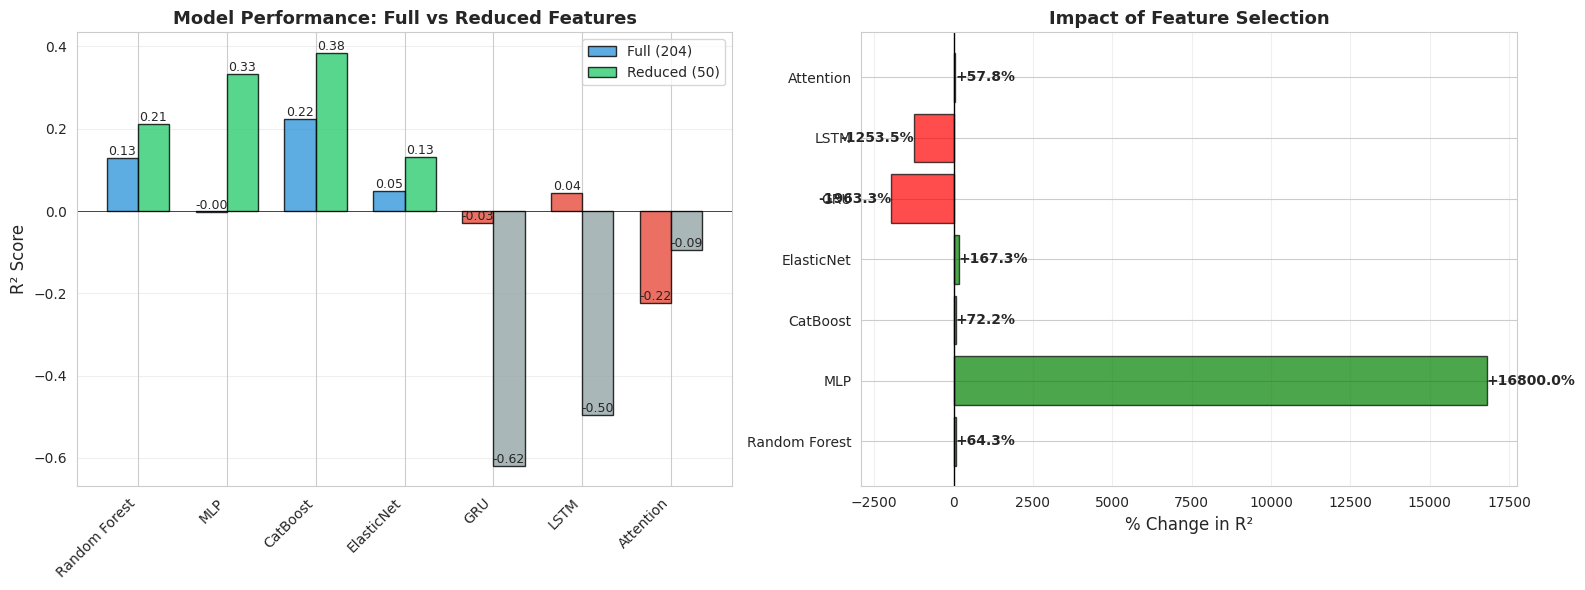


Figure saved to /home/bendavison/PycharmProjects/msc_dissertation/results/feature_selection_50_comparison.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Extract numeric values
models = comparison['Model'].values
full_scores = comparison['Full (204)'].astype(float).values
reduced_scores = comparison[f'Reduced ({N_FEATURES})'].astype(float).values
types = comparison['Type'].values

# Plot 1: Grouped bar chart
x = np.arange(len(models))
width = 0.35

colors_full = ['#3498db' if t == 'Flat' else '#e74c3c' for t in types]
colors_reduced = ['#2ecc71' if t == 'Flat' else '#95a5a6' for t in types]

bars1 = ax1.bar(x - width/2, full_scores, width, label='Full (204)', alpha=0.8, color=colors_full, edgecolor='black')
bars2 = ax1.bar(x + width/2, reduced_scores, width, label=f'Reduced ({N_FEATURES})', alpha=0.8, color=colors_reduced, edgecolor='black')

ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Model Performance: Full vs Reduced Features', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)


for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Change percentages
changes_pct = [(reduced_scores[i] - full_scores[i]) / abs(full_scores[i]) * 100 for i in range(len(models))]
colors_change = ['green' if c > 0 else 'red' for c in changes_pct]

bars = ax2.barh(models, changes_pct, color=colors_change, alpha=0.7, edgecolor='black')
ax2.set_xlabel('% Change in R²', fontsize=12)
ax2.set_title('Impact of Feature Selection', fontsize=13, fontweight='bold')
ax2.axvline(x=0, color='k', linestyle='-', linewidth=1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (model, change) in enumerate(zip(models, changes_pct)):
    ax2.text(change + (2 if change > 0 else -2), i, f'{change:+.1f}%',
            va='center', ha='left' if change > 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'feature_selection_{N_FEATURES}_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to {RESULTS_DIR / f'feature_selection_{N_FEATURES}_comparison.png'}")

## Step 9: Save Results

In [15]:
# Package all results
results_reduced = {
    'RF': rf_reduced,
    'MLP': mlp_reduced,
    'CatBoost': cb_reduced,
    'ElasticNet': en_reduced,
    'LSTM': lstm_reduced,
    'GRU': gru_reduced,
    'Attention': attention_reduced
}

with open(RESULTS_DIR / f'reduced_features_{N_FEATURES}_results.pkl', 'wb') as f:
    pickle.dump(results_reduced, f)

# Save comparison table
comparison.to_csv(RESULTS_DIR / f'feature_selection_{N_FEATURES}_comparison.csv', index=False)

# Save feature list
top_n_df = importance_df.head(N_FEATURES).reset_index(drop=True)
top_n_df['rank'] = range(1, N_FEATURES + 1)
top_n_df = top_n_df[['rank', 'feature', 'importance']]
top_n_df.to_csv(RESULTS_DIR / f'top_{N_FEATURES}_features.csv', index=False)

print("✅ Results saved:")
print(f"  - {RESULTS_DIR / f'reduced_features_{N_FEATURES}_results.pkl'}")
print(f"  - {RESULTS_DIR / f'feature_selection_{N_FEATURES}_comparison.csv'}")
print(f"  - {RESULTS_DIR / f'top_{N_FEATURES}_features.csv'}")

✅ Results saved:
  - /home/bendavison/PycharmProjects/msc_dissertation/results/reduced_features_50_results.pkl
  - /home/bendavison/PycharmProjects/msc_dissertation/results/feature_selection_50_comparison.csv
  - /home/bendavison/PycharmProjects/msc_dissertation/results/top_50_features.csv
